## Amazon E-comm Sales & Customer Behavior Analysis
### Project Overview
#### In this project, I analyze Amazon transactions in January 2023 to uncover key business insights such as sales trends, customer behavior, product performance, and revenue drivers.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


### Data Preparation:
#### Here I do some cleaning and conversions to ensure data is ready for analysis. 

In [10]:
# Remove currency symbols and commas
df['discounted_price'] = (
    df['discounted_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

df['actual_price'] = (
    df['actual_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

df['discount_percentage'] = (
    df['discount_percentage']
    .str.replace('%', '', regex=False)
    .astype(float)
)

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = (
    df['rating_count']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [11]:
 # Indian Rupee to US Dollars exchange rate assumption. 
INR_TO_USD = 83 

df['actual_price_usd'] = df['actual_price'] / INR_TO_USD
df['discounted_price_usd'] = df['discounted_price'] / INR_TO_USD
df[['actual_price', 'actual_price_usd',
    'discounted_price', 'discounted_price_usd']].head()


,actual_price,actual_price_usd,discounted_price,discounted_price_usd
0,1099.0,13.240964,399.0,4.807229
1,349.0,4.204819,199.0,2.397590
2,1899.0,22.879518,199.0,2.397590
3,699.0,8.421687,329.0,3.963855
4,399.0,4.807229,154.0,1.855422


In [12]:
df.isna().sum()

product_id              0
product_name            0
category                0
discounted_price        0
actual_price            0
discount_percentage     0
rating                  1
rating_count            2
about_product           0
user_id                 0
user_name               0
review_id               0
review_title            0
review_content          0
img_link                0
product_link            0
actual_price_usd        0
discounted_price_usd    0
dtype: int64

## Exploratory Data Analysis
### Summary Statistics, Initial Visualizations, and Data Distributions

### Insights:
#### Most products cluster between 4.0–4.5, suggesting rating inflation or selection bias.

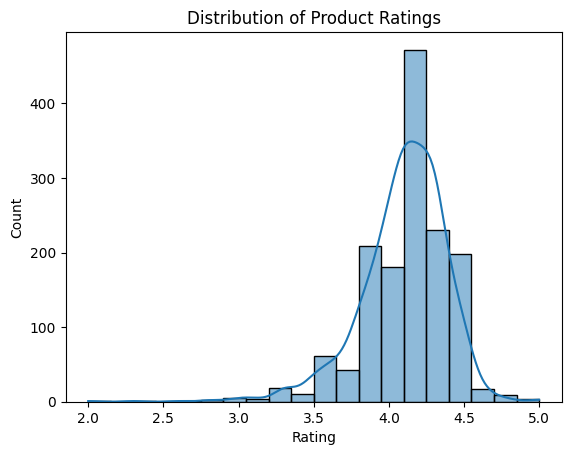

In [13]:
sns.histplot(df['rating'].dropna(), bins=20, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Insights:
#### Discounted prices scale proportionally with actual prices — discounts are largely percentage-based.

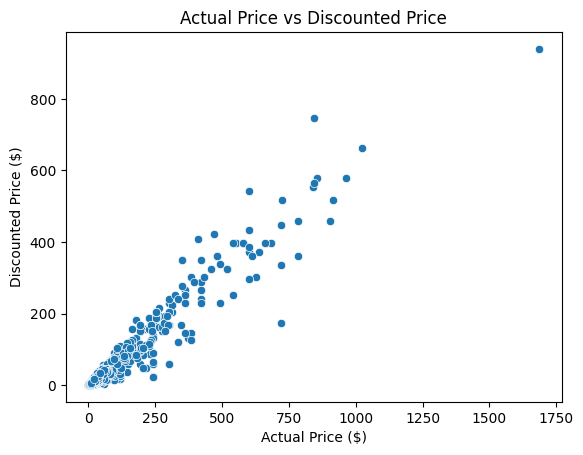

In [14]:
sns.scatterplot(
    x='actual_price_usd',
    y='discounted_price_usd',
    data=df
)
plt.title("Actual Price vs Discounted Price")
plt.xlabel("Actual Price ($)")
plt.ylabel("Discounted Price ($)")
plt.show()

### Insights:
#### Highly rated categories are not always the most populated — quality ≠ quantity.

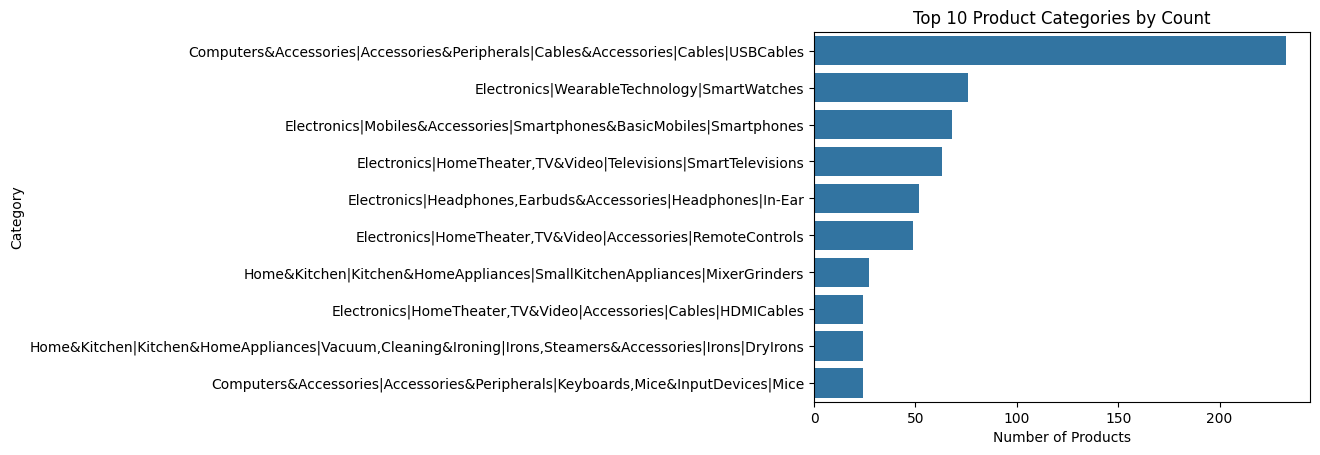

In [18]:

# Barplot 1. Number of Products by Category
top_categories = df['category'].value_counts().head(10)

sns.barplot(
    y=top_categories.index,
    x=top_categories.values
)
plt.title("Top 10 Product Categories by Count")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()


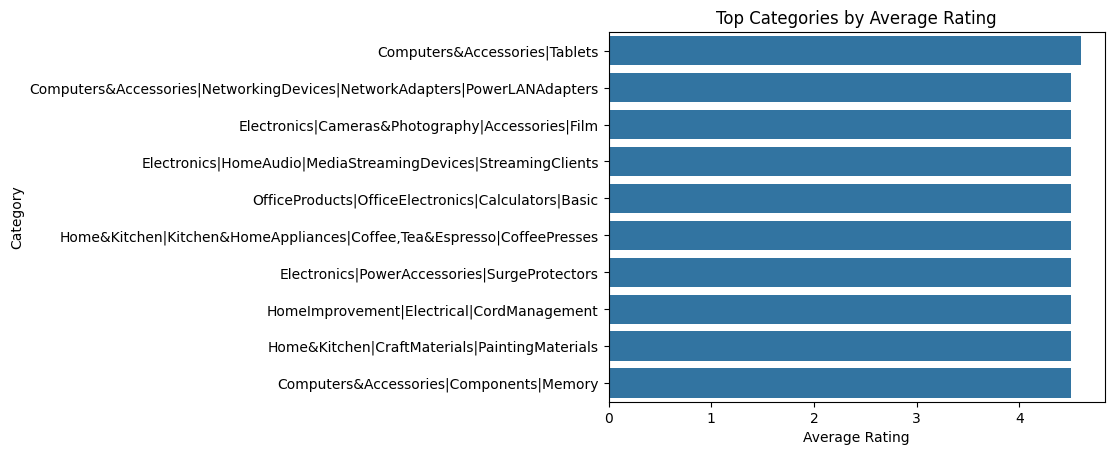

In [17]:
# Barplot 2. Avg Rating by Category
avg_rating = (
    df.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)
plt.title("Top Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.show()


### Insights:
#### Why log scale? Rating counts are heavily right-skewed — this makes patterns visible.
#### Large discounts don’t guarantee engagement, but moderate discounts often align with higher visibility.

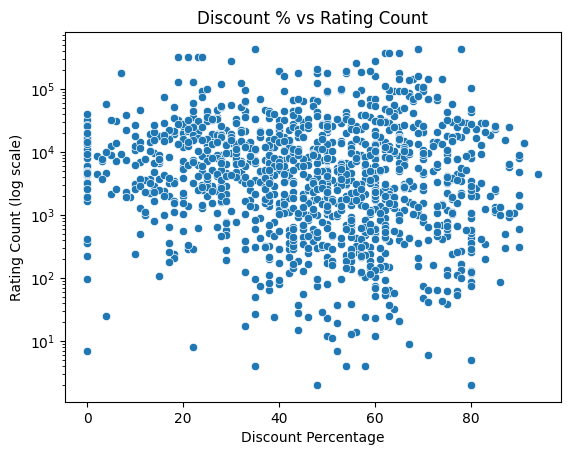

In [12]:
sns.scatterplot(
    x='discount_percentage',
    y='rating_count',
    data=df
)
plt.yscale('log')
plt.title("Discount % vs Rating Count")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating Count (log scale)")
plt.show()


### Top 10 Products (January 2023)

In [13]:
top_products = df.sort_values(
    'rating_count',
    ascending=False
).head(10)

top_products[['product_name', 'category', 'rating', 'rating_count']]


,product_name,category,rating,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,4.1,313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,4.1,313836.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",Electronics|Mobiles&Accessories|Smartphones&Ba...,4.1,313832.0


### Final Insights:
#### A small number of products dominate customer attention — classic power-law behavior.

##### \* Ratings cluster tightly around 4–4.5

##### \* Discount strategies are consistent across price ranges

##### \* Category size does not correlate strongly with quality

##### \* Moderate discounts + strong ratings drive engagement

##### \* A few products account for most customer reviews

###  Business Recommendations

##### \* Focus promotions on high-rated, mid-discount products

##### \* Invest in visibility for smaller but high-quality categories

##### \* Avoid deep discounting without strong product quality signals